# Download 100 COCO Val Images

In [1]:
!pip install pycocotools -q

In [2]:
%matplotlib inline
from pycocotools.coco import COCO
import skimage.io as io
import matplotlib.pyplot as plt
import numpy as np
import os
import pylab
pylab.rcParams['figure.figsize'] = (8.0, 10.0)

dataDir  = '/content/coco'
dataType = 'val2017'
imgDir   = f'{dataDir}/images/{dataType}'

In [3]:
# Download and extract val2017.zip (~1 GB)
import urllib.request, zipfile

zip_url  = 'http://images.cocodataset.org/zips/val2017.zip'
zip_path = '/tmp/val2017.zip'

if not os.path.exists(imgDir):
    print('Downloading val2017.zip (~1 GB)...')

    def progress(count, block, total):
        pct = count * block / total * 100
        print(f'\r  {pct:.1f}%', end='', flush=True)

    urllib.request.urlretrieve(zip_url, zip_path, reporthook=progress)
    print('\nExtracting...')
    with zipfile.ZipFile(zip_path, 'r') as z:
        z.extractall(f'{dataDir}/images')
    os.remove(zip_path)
    print(f'✅ Done. {len(os.listdir(imgDir))} images extracted.')
else:
    print(f'✅ Already extracted. {len(os.listdir(imgDir))} images found.')

  100.0%
Extracting...
✅ Done. 5000 images extracted.


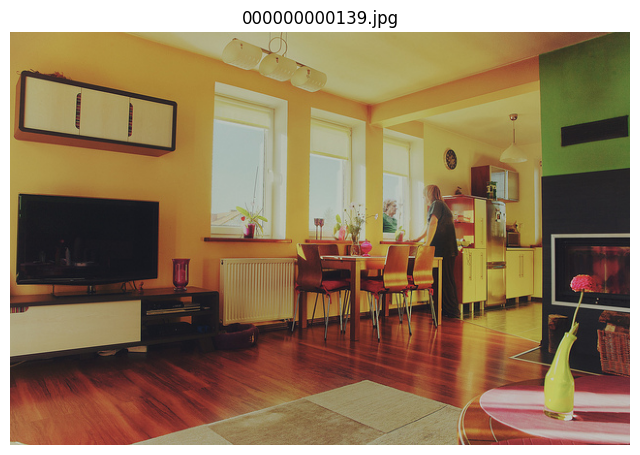

In [4]:
# Load 100 images from disk — exactly like pycocoDemo
N = 100
img_files = sorted(os.listdir(imgDir))[:N]

# Display one
I = io.imread(f'{imgDir}/{img_files[0]}')
plt.axis('off')
plt.imshow(I)
plt.title(img_files[0])
plt.show()

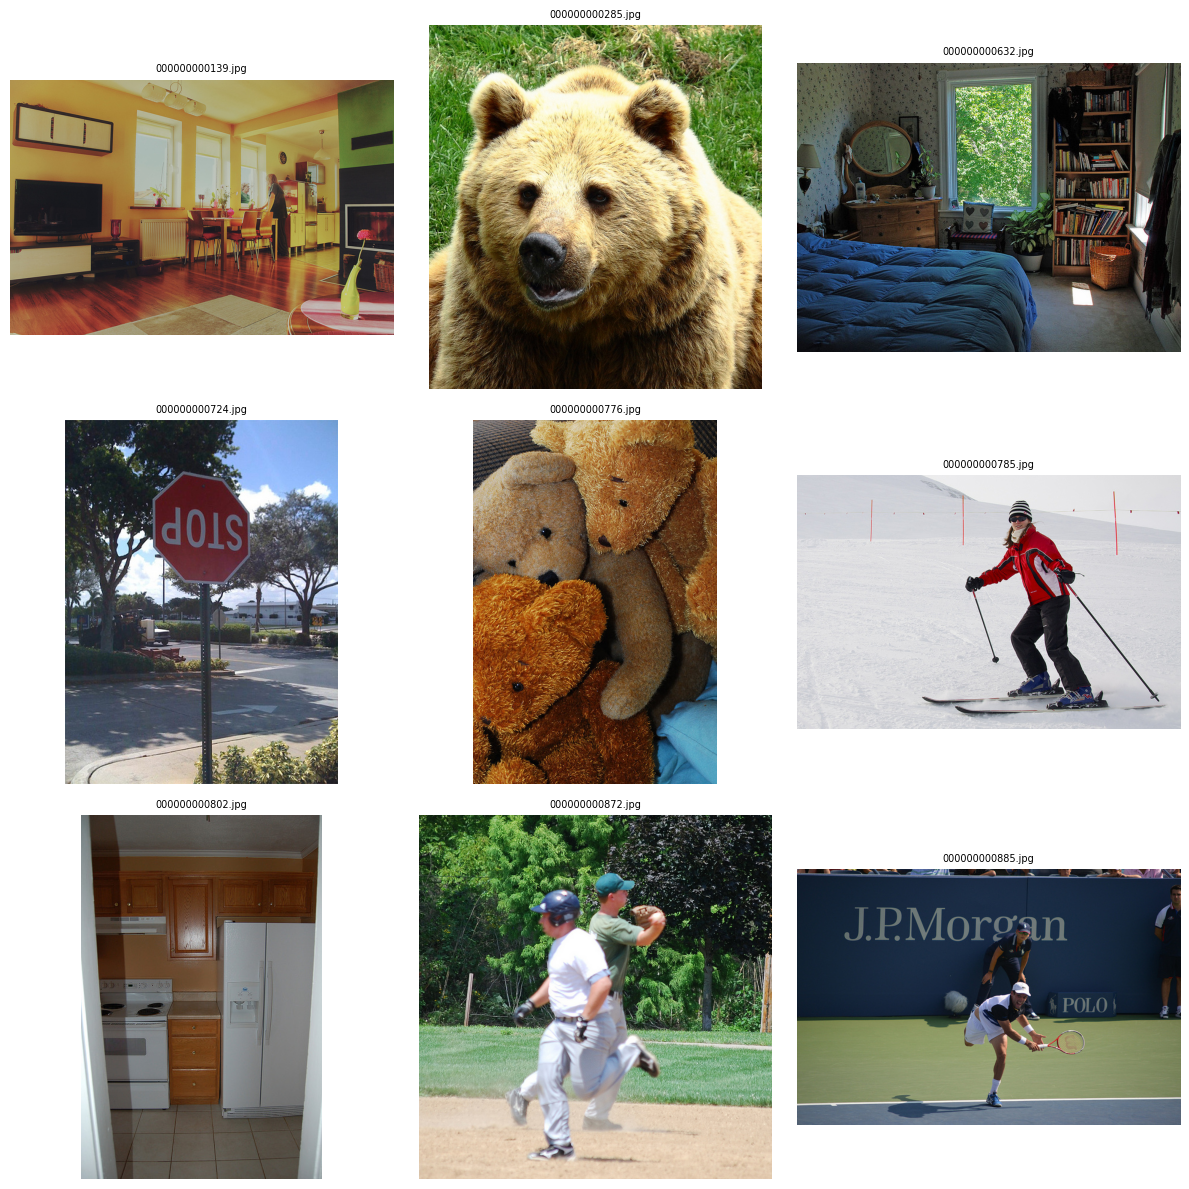

In [5]:
# Preview grid — 9 images from disk
fig, axes = plt.subplots(3, 3, figsize=(12, 12))
for ax, fname in zip(axes.flat, img_files[:9]):
    I = io.imread(f'{imgDir}/{fname}')
    ax.imshow(I)
    ax.axis('off')
    ax.set_title(fname, fontsize=7)
plt.tight_layout()
plt.show()

In [6]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [7]:
import shutil

drive_path = '/content/drive/MyDrive/CS4782-Final-Project/coco_val_images'


if not os.path.exists(drive_path):
    os.makedirs(drive_path)
    print(f'Created folder: {drive_path}')
else:
    print(f'Folder already exists: {drive_path}')

print(f'Saving {len(img_files)} images to Google Drive...')
for i, fname in enumerate(img_files):
    src_path = os.path.join(imgDir, fname)
    dst_path = os.path.join(drive_path, fname)
    shutil.copy(src_path, dst_path)
    if (i + 1) % 10 == 0:
        print(f'  Copied {i + 1} images...')

print(f'\n✅ Done. All {len(img_files)} images saved to {drive_path}')

Created folder: /content/drive/MyDrive/CS4782-Final-Project/coco_val_images
Saving 100 images to Google Drive...
  Copied 10 images...
  Copied 20 images...
  Copied 30 images...
  Copied 40 images...
  Copied 50 images...
  Copied 60 images...
  Copied 70 images...
  Copied 80 images...
  Copied 90 images...
  Copied 100 images...

✅ Done. All 100 images saved to /content/drive/MyDrive/CS4782-Final-Project/coco_val_images
